# 20. Final baseline regression model

This notebook creates the **demographic-only baseline regression model** for the manuscript revision.

Purpose:

- Use the same train/test split as the CNN regression analysis.
- Use only the demographic/body-mass variables already included in the CNN metadata branch:
  - `RIAGENDR` = sex
  - `RIDAGEYR` = age
  - `BMXWT` = body mass
- Fit a simple linear regression model.
- Evaluate it once on the held-out test set.
- Save final test-set metrics and predictions.

Outcome:

- `DXXNK_TSCORE`: femoral neck T-score derived from DXA-measured femoral neck BMD.

This baseline helps contextualize whether GAF-encoded accelerometry tensors add predictive value beyond simple demographic/body-mass information.


## 1. Imports and settings

In [1]:
import os
import platform
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
)
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import sklearn

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Adjust this path if the CSV files are stored elsewhere.
DATA_DIR = "."

# Output files will be saved here.
OUTPUT_DIR = "."

BASELINE_FEATURES = ["RIAGENDR", "RIDAGEYR", "BMXWT"]

print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)


Python: 3.11.3
NumPy: 1.26.3
pandas: 2.1.4
scikit-learn: 1.8.0


## 2. Load the existing train/test split

This notebook assumes that the following files already exist from the preprocessing pipeline:

- `X_train.csv`
- `X_test.csv`
- `y_train_regression.csv`
- `y_test_regression.csv`

These are the same split files used in the original regression notebook and should correspond to the 80/20 train/test split used in the CNN analysis.


In [2]:
X_train_full = pd.read_csv(os.path.join(DATA_DIR, "X_train.csv"))
X_test_full = pd.read_csv(os.path.join(DATA_DIR, "X_test.csv"))

y_train_df = pd.read_csv(os.path.join(DATA_DIR, "y_train_regression.csv"))
y_test_df = pd.read_csv(os.path.join(DATA_DIR, "y_test_regression.csv"))

# Convert target files to 1D arrays.
y_train = y_train_df.squeeze().to_numpy(dtype=np.float32)
y_test = y_test_df.squeeze().to_numpy(dtype=np.float32)

print("X_train shape:", X_train_full.shape)
print("X_test shape:", X_test_full.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train_full.head()


X_train shape: (2003, 9)
X_test shape: (501, 9)
y_train shape: (2003,)
y_test shape: (501,)


,SEQN,RIAGENDR,RIDAGEYR,BMXWT,PAXMINSB,PAXMINLPA,PAXMINMPA,PAXMINVPA,PAXMINVVPA
0,76988.0,1.0,67.0,68.3,55.180460,271.081575,226.268674,20.398862,0.425658
1,82083.0,2.0,57.0,67.4,54.249962,349.396124,403.947424,111.523810,11.183867
2,75435.0,2.0,63.0,60.3,75.901543,298.740069,458.557302,63.265076,2.150472
3,76741.0,2.0,68.0,70.1,84.972456,257.353975,277.324868,45.859348,2.212542
4,78834.0,2.0,56.0,57.1,48.954254,330.458856,458.479079,84.496932,5.680614


## 3. Basic checks

We keep `SEQN` separately only for the saved predictions. It is **not** used as a predictor.


In [3]:
# Keep participant identifiers for the predictions file, if available.
test_seqn = X_test_full["SEQN"].copy() if "SEQN" in X_test_full.columns else pd.Series(np.arange(len(X_test_full)), name="row_id")

# Check that the required baseline predictors are available.
missing_features = [col for col in BASELINE_FEATURES if col not in X_train_full.columns]

if missing_features:
    raise ValueError(f"Missing required baseline features: {missing_features}")

# Select only the demographic/body-mass predictors.
X_train = X_train_full[BASELINE_FEATURES].copy()
X_test = X_test_full[BASELINE_FEATURES].copy()

print("Baseline predictors:", BASELINE_FEATURES)

print("\nOutcome summary, training set:")
print(pd.Series(y_train).describe())

print("\nOutcome summary, test set:")
print(pd.Series(y_test).describe())

print("\nMissing values in training predictors:")
print(X_train.isna().sum())

print("\nMissing values in test predictors:")
print(X_test.isna().sum())

X_train.head()


Baseline predictors: ['RIAGENDR', 'RIDAGEYR', 'BMXWT']

Outcome summary, training set:
count    2003.000000
mean       -0.575083
std         1.194663
min        -3.708333
25%        -1.416667
50%        -0.650000
75%         0.166667
max         4.191667
dtype: float64

Outcome summary, test set:
count    501.000000
mean      -0.528809
std        1.256569
min       -3.658333
25%       -1.408333
50%       -0.600000
75%        0.216667
max        4.091667
dtype: float64

Missing values in training predictors:
RIAGENDR    0
RIDAGEYR    0
BMXWT       0
dtype: int64

Missing values in test predictors:
RIAGENDR    0
RIDAGEYR    0
BMXWT       0
dtype: int64


,RIAGENDR,RIDAGEYR,BMXWT
0,1.0,67.0,68.3
1,2.0,57.0,67.4
2,2.0,63.0,60.3
3,2.0,68.0,70.1
4,2.0,56.0,57.1


## 4. Define the demographic-only linear regression pipeline

The baseline model is intentionally simple:

1. Median imputation for any missing values.
2. Standardization of predictors.
3. Linear regression.

No accelerometry-derived tensor or GAF information is used in this baseline.


In [4]:
baseline_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("linear_regression", LinearRegression()),
    ]
)

baseline_model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

## 5. Internal cross-validation on the training set

This step documents training-set performance and reproducibility.

The final manuscript values should come from the untouched test set in the next section.


In [5]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = cross_validate(
    baseline_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "r2": "r2",
        "neg_mse": "neg_mean_squared_error",
        "neg_mae": "neg_mean_absolute_error",
    },
    return_train_score=False,
)

cv_summary = pd.DataFrame(
    {
        "Metric": ["R2", "MSE", "RMSE", "MAE"],
        "Mean": [
            cv_results["test_r2"].mean(),
            (-cv_results["test_neg_mse"]).mean(),
            np.sqrt((-cv_results["test_neg_mse"]).mean()),
            (-cv_results["test_neg_mae"]).mean(),
        ],
        "SD": [
            cv_results["test_r2"].std(),
            (-cv_results["test_neg_mse"]).std(),
            np.sqrt((-cv_results["test_neg_mse"])).std(),
            (-cv_results["test_neg_mae"]).std(),
        ],
    }
)

cv_summary


,Metric,Mean,SD
0,R2,0.296793,0.045149
1,MSE,0.999860,0.093551
2,RMSE,0.999930,0.046502
3,MAE,0.782952,0.039562


## 6. Fit the final baseline model on the full training set

In [6]:
baseline_model.fit(X_train, y_train)

y_pred_train = baseline_model.predict(X_train)
y_pred = baseline_model.predict(X_test)


## 7. Final test-set evaluation

These are the values to compare against the CNN regression metrics.

Definitions:

- **R²** = proportion of variance explained.
- **MSE** = mean squared error.
- **RMSE** = root mean squared error.
- **MAE** = mean absolute error.

All errors are in femoral neck T-score units.


In [7]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

baseline_results = {
    "Model": "Demographic-only linear regression",
    "R2": r2,
    "MSE": mse,
    "RMSE": rmse,
    "MAE": mae,
}

baseline_results_df = pd.DataFrame([baseline_results])
baseline_results_df


,Model,R2,MSE,RMSE,MAE
0,Demographic-only linear regression,0.345626,1.031173,1.015467,0.772009


## 8. Model coefficients

The coefficients are based on standardized predictors because the model is fitted within a pipeline using `StandardScaler`.


In [8]:
linear_model = baseline_model.named_steps["linear_regression"]

coefs = pd.DataFrame(
    {
        "Feature": BASELINE_FEATURES,
        "Coefficient_standardized": linear_model.coef_,
    }
)

coefs.loc[len(coefs)] = ["Intercept", linear_model.intercept_]

coefs


,Feature,Coefficient_standardized
0,RIAGENDR,-0.158417
1,RIDAGEYR,-0.317227
2,BMXWT,0.488103
3,Intercept,-0.575083


## 9. Diagnostic plots

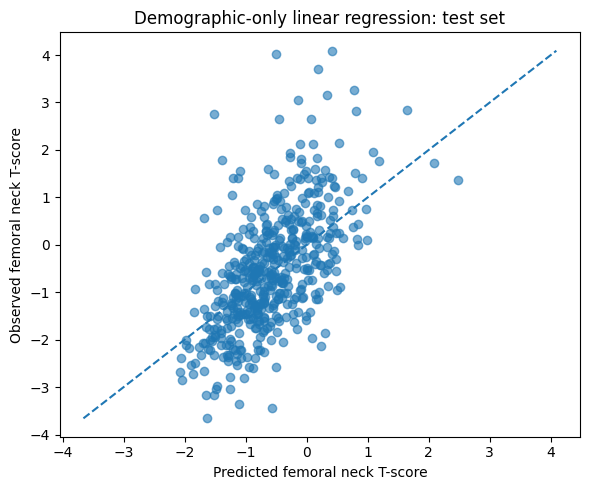

In [9]:
plt.figure(figsize=(6, 5))
plt.scatter(y_pred, y_test, alpha=0.6)

min_value = min(np.min(y_test), np.min(y_pred))
max_value = max(np.max(y_test), np.max(y_pred))
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.xlabel("Predicted femoral neck T-score")
plt.ylabel("Observed femoral neck T-score")
plt.title("Demographic-only linear regression: test set")
plt.tight_layout()
plt.show()


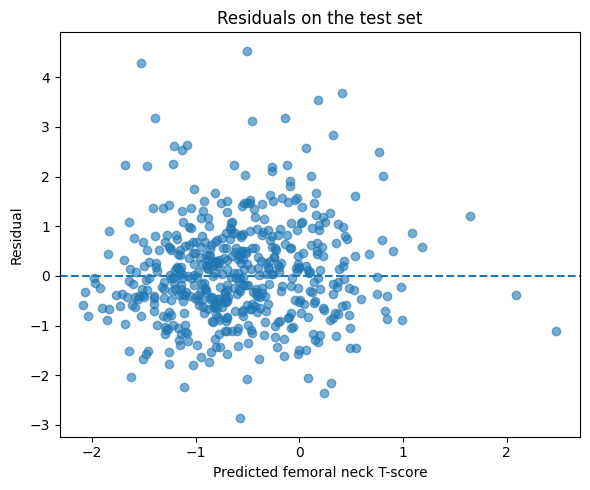

In [10]:
residuals = y_test - y_pred

plt.figure(figsize=(6, 5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted femoral neck T-score")
plt.ylabel("Residual")
plt.title("Residuals on the test set")
plt.tight_layout()
plt.show()


## 10. Save outputs

In [11]:
baseline_predictions = pd.DataFrame(
    {
        "SEQN": test_seqn.to_numpy(),
        "y_true": y_test,
        "y_pred": y_pred,
        "residual": y_test - y_pred,
    }
)

metrics_path = os.path.join(OUTPUT_DIR, "baseline_regression_test_metrics.csv")
predictions_path = os.path.join(OUTPUT_DIR, "baseline_regression_test_predictions.csv")
cv_path = os.path.join(OUTPUT_DIR, "baseline_regression_cv_metrics.csv")
coefs_path = os.path.join(OUTPUT_DIR, "baseline_regression_coefficients.csv")

baseline_results_df.to_csv(metrics_path, index=False)
baseline_predictions.to_csv(predictions_path, index=False)
cv_summary.to_csv(cv_path, index=False)
coefs.to_csv(coefs_path, index=False)

print("Saved:", metrics_path)
print("Saved:", predictions_path)
print("Saved:", cv_path)
print("Saved:", coefs_path)


Saved: .\baseline_regression_test_metrics.csv
Saved: .\baseline_regression_test_predictions.csv
Saved: .\baseline_regression_cv_metrics.csv
Saved: .\baseline_regression_coefficients.csv


## 11. Optional comparison with CNN regression metrics

Run this cell only if `cnn_regression_test_metrics.csv` is available in the same folder.

This creates a compact comparison table between the demographic-only baseline and the CNN models.


In [12]:
cnn_metrics_path = os.path.join(OUTPUT_DIR, "cnn_regression_test_metrics.csv")

if os.path.exists(cnn_metrics_path):
    cnn_metrics = pd.read_csv(cnn_metrics_path)

    comparison = pd.concat(
        [
            baseline_results_df,
            cnn_metrics,
        ],
        ignore_index=True,
        sort=False,
    )

    comparison_columns = ["Model", "R2", "MSE", "RMSE", "MAE"]
    comparison = comparison[comparison_columns]
    comparison.to_csv(os.path.join(OUTPUT_DIR, "regression_baseline_vs_cnn_metrics.csv"), index=False)
    display(comparison)
else:
    print("CNN metrics file not found:", cnn_metrics_path)


,Model,R2,MSE,RMSE,MAE
0,Demographic-only linear regression,0.345626,1.031173,1.015467,0.772009
1,ResNet,0.118087,1.389732,1.178869,0.957595
2,VGG,0.304923,1.095313,1.046572,0.789122


## 12. Manuscript-ready sentence template

After running the notebook, use the generated table to adapt this sentence:

> As a demographic-only reference model, linear regression using sex, age, and body mass achieved a test R² of X, MSE of X, RMSE of X, and MAE of X for femoral neck T-score prediction. This baseline was included to contextualize the performance of the GAF-CNN models.
